In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("adult_income.csv")

# Clean strings
for col in df.select_dtypes(include='object'):
    df[col] = df[col].str.strip()

# Encode target
df['income'] = LabelEncoder().fit_transform(df['income'])

# One-hot encode features
X = pd.get_dummies(df.drop(columns='income'))
y = df['income']

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.int64)

# Create DataLoader
dataset = TensorDataset(X_tensor)
loader = DataLoader(dataset, batch_size=128, shuffle=True)


In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.fc_decode1 = nn.Linear(latent_dim, 128)
        self.fc_out = nn.Linear(128, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc_decode1(z))
        return torch.sigmoid(self.fc_out(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar


Epoch 1, Loss: 107.26
Epoch 2, Loss: 102.97
Epoch 3, Loss: 102.31
Epoch 4, Loss: 101.66
Epoch 5, Loss: 101.00
Epoch 6, Loss: 100.38
Epoch 7, Loss: 99.95
Epoch 8, Loss: 99.64
Epoch 9, Loss: 99.43
Epoch 10, Loss: 99.21
Epoch 11, Loss: 99.02
Epoch 12, Loss: 98.88
Epoch 13, Loss: 98.74
Epoch 14, Loss: 98.63
Epoch 15, Loss: 98.54
Epoch 16, Loss: 98.45
Epoch 17, Loss: 98.39
Epoch 18, Loss: 98.33
Epoch 19, Loss: 98.25
Epoch 20, Loss: 98.17
Epoch 21, Loss: 98.13
Epoch 22, Loss: 98.08
Epoch 23, Loss: 98.04
Epoch 24, Loss: 97.96
Epoch 25, Loss: 97.92
Epoch 26, Loss: 97.88
Epoch 27, Loss: 97.82
Epoch 28, Loss: 97.81
Epoch 29, Loss: 97.78
Epoch 30, Loss: 97.76
Epoch 31, Loss: 97.71
Epoch 32, Loss: 97.68
Epoch 33, Loss: 97.65
Epoch 34, Loss: 97.64
Epoch 35, Loss: 97.64
Epoch 36, Loss: 97.59
Epoch 37, Loss: 97.58
Epoch 38, Loss: 97.54
Epoch 39, Loss: 97.53
Epoch 40, Loss: 97.51
Epoch 41, Loss: 97.46
Epoch 42, Loss: 97.43
Epoch 43, Loss: 97.43
Epoch 44, Loss: 97.42
Epoch 45, Loss: 97.41
Epoch 46, Los

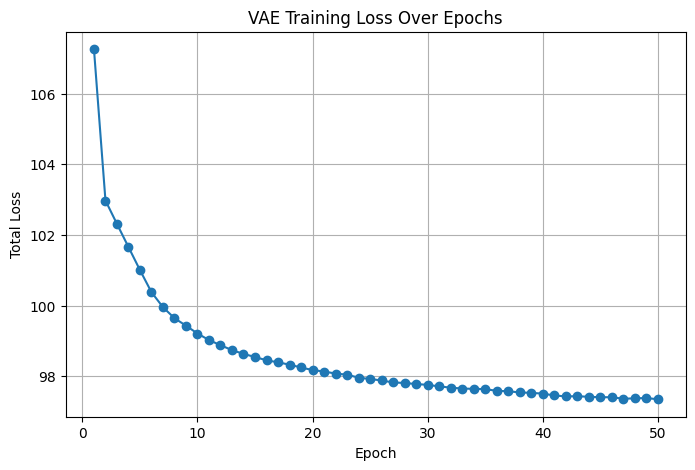

In [6]:
def vae_loss(x_recon, x, mu, logvar):
    recon_loss = nn.functional.mse_loss(x_recon, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

vae = VAE(input_dim=X_tensor.shape[1], latent_dim=2)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)
vae.train()

epoch_losses = []  # Track total loss per epoch

for epoch in range(50):
    total_loss = 0
    for (x_batch,) in loader:
        optimizer.zero_grad()
        x_recon, mu, logvar = vae(x_batch)
        loss = vae_loss(x_recon, x_batch, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(X_tensor)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.2f}")


plt.figure(figsize=(8, 5))
plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o')
plt.title("VAE Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.grid(True)
plt.show()

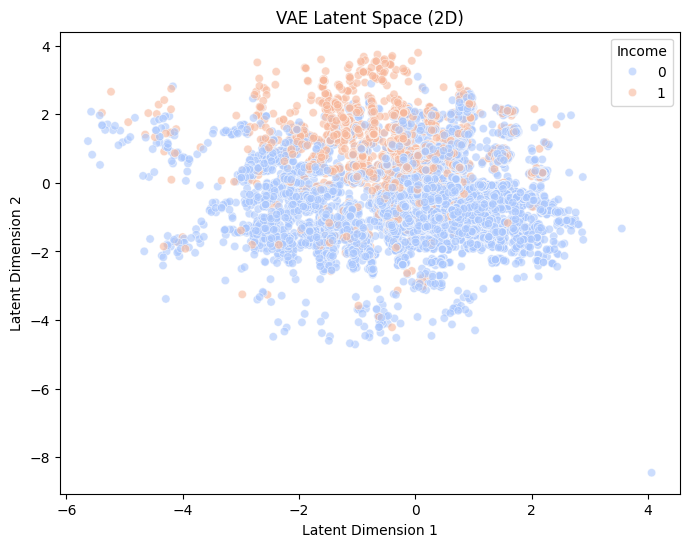

In [7]:
vae.eval()
with torch.no_grad():
    mu, _ = vae.encode(X_tensor)

# Convert to NumPy for plotting
latent_2d = mu.numpy()

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=latent_2d[:, 0], y=latent_2d[:, 1], hue=y, palette='coolwarm', alpha=0.6)
plt.title("VAE Latent Space (2D)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.legend(title='Income')
plt.show()
